In [1]:
import numpy as np
import pandas as pd
import h5py
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator,LogLocator,NullFormatter)
from matplotlib.colors import LogNorm
import glob
import yaml
from astropy.cosmology import Planck15,z_at_value
from astropy import units as u
from scipy.interpolate import interp1d

In [3]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.sans-serif'] = ['Bitstream Vera Sans']
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['axes.unicode_minus'] = False

import seaborn as sns
sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('colorblind')
colors=sns.color_palette('colorblind')
fs=30

In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

In [6]:
plt.rcParams.update(plt.rcParamsDefault)

In [7]:
import arviz as az

In [8]:
from gwdistributions.distributions.spin.effective import IsotropicUniformMagnitudeChiEffGivenComponentMass

/home/omkar.sridhar/.conda/envs/gppop-dev-spin/lib/python3.9/site-packages/gwdistributions/transforms/location.py:10: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal.lal import GreenwichMeanSiderealTime as GMST


The pyseobnr package has failed to load, you will not be able to employ SEOBNRv5 approximants.


In [9]:
from gppop.core import Utils_spins,Utils,Utils_spins_with_q,Vt_Utils_spins,Vt_Utils_spins_with_q, Rates_spins,Rates_spins_with_q, Post_Proc_Utils_spins,Post_Proc_Utils_spins_with_q

In [10]:
import os
os.getcwd()

'/home/omkar.sridhar/NU_project_BGP/bbh-subpopulations-scripts'

## GWTC-3 prod results (Figure 1)

In [11]:
run_dir = 'run-dir-gwtc4/Case_9mdo/'
plot_dir = 'plots/gwtc-4-prod_case_9mdo/'
if not(os.path.exists(plot_dir)):
    os.makedirs(plot_dir)
mbins = np.loadtxt(run_dir+'mbins_with_q_case_9mdo.txt')
qbins = np.loadtxt(run_dir + 'qbins_with_q_case_9mdo.txt')
chi_bins = np.loadtxt(run_dir+'chi_bins_new3_with_q_case_9mdo.txt')
label = 'gwtc4'
trace = az.from_netcdf(run_dir+'gppop_GWTC4_posterior_newbins3_kappa_corr_with_q_n_eff44_opt_case_9mdo.nc')

In [12]:
N_samples = int(len(trace['posterior']['draw'])*len(trace['posterior']['chain']))
nbins_m = len(mbins)-1
nbins_q = len(qbins) - 1
nbins_chi = len(chi_bins)-1

n_corr_samples = np.array([trace['posterior']['n_corr'].to_numpy()[:,:,i].reshape((N_samples,)) for i in range(nbins_m*nbins_q*nbins_chi)]).T
n_corr_samples.shape

(36000, 2640)

In [14]:
pp_utils = Post_Proc_Utils_spins_with_q(mbins,qbins,chi_bins,kappa=2.7)

In [15]:
pp_utils.get_arviz_stats_with_q(trace)

{'Neff': 151.2213577021136, 'Rhat': 1.0253842228766048}

In [16]:
wt_means = np.loadtxt(run_dir+'wt_means_GWTC4_newbins3_with_q_case_9mdo.txt')
wt_sigmas = np.loadtxt(run_dir+'wt_sigmas_GWTC4_newbins3_with_q_case_9mdo.txt')

In [17]:
utils = Utils_spins_with_q(mbins,qbins,chi_bins,kappa=2.7)

In [18]:
dm1 = utils.delta_logm1s_for_q(mbins)
dq = utils.delta_qs_for_q(mbins)
log_bin_centers = utils.generate_log_bin_centers_with_q()
d_chis = utils.delta_chis_for_q()

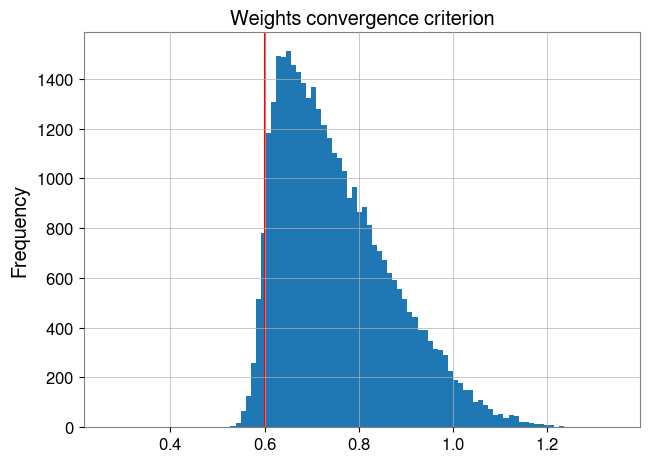

In [20]:
Neff = []
for this_n_corr in n_corr_samples:  
    denominator = np.sum((wt_sigmas*this_n_corr[None,:])**2, axis =-1)
    numerator = np.dot(wt_means, this_n_corr)**2
    Neff.append(min(numerator/denominator))


plt.hist(np.log10(Neff), bins = 100)
plt.axvline(0.6, color = 'r')
#plt.show()

plt.title('Weights convergence criterion')

plt.tight_layout()
plt.ylabel('Frequency')

plt.show()

In [21]:
Neffarr = np.array(Neff)
np.where(np.log10(Neffarr) < 0.6)[0].shape

(1570,)

In [22]:
n_corr_samples_copy = np.copy(n_corr_samples)
n_corr_samples_copy = np.delete(n_corr_samples_copy, np.where(np.log10(Neffarr) < 0.6)[0], 0)

In [23]:
n_corr_samples = np.copy(n_corr_samples_copy)
n_corr_samples.shape

(34430, 2640)

In [24]:
vt_means = np.loadtxt(run_dir+'vt_means_GWTC4_newbins3_with_q_case_9mdo.txt')
vt_sigmas = np.loadtxt(run_dir+'vt_sigmas_GWTC4_newbins3_with_q_case_9mdo.txt')
vt_sigmas += 1e-310

In [25]:
vt_cond = (np.sum((vt_means/vt_sigmas) ** 2) / np.dot(n_corr_samples, vt_means)) 
vt_cond

array([2122.04438819, 2701.46185524, 2717.91800841, ...,
       2071.04630859, 2624.63936829, 2439.17747054])

Text(39.24611409505208, 0.5, 'Frequency')

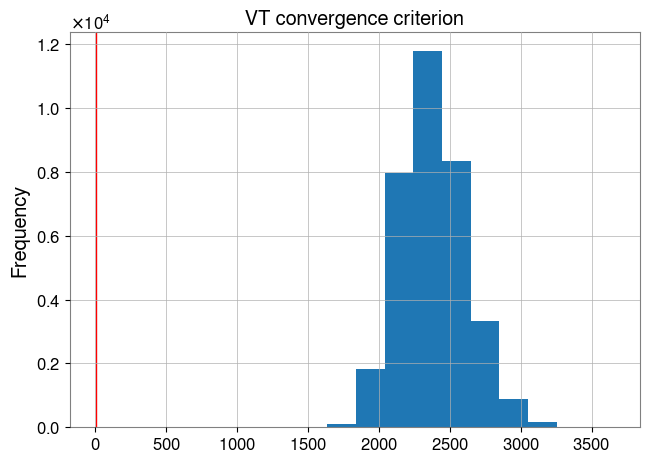

In [26]:
plt.hist(vt_cond, bins = 10)
plt.axvline(2, color='r', linewidth=1)

plt.title('VT convergence criterion')

plt.tight_layout()
plt.ylabel('Frequency')

#plt.savefig(plot_dir+'vt_cond_hist_case_6.pdf')

In [27]:
np.where(vt_cond < 2)

(array([], dtype=int64),)

# Pearson correlation coefficient

In [28]:
rho_m1_7p5_to_15_test = pp_utils.get_pearson_coeff_mass_range_with_q(n_corr_samples, dm1, dq, d_chis, log_bin_centers, 7, 16.2)
rho_m1_30_to_40_test = pp_utils.get_pearson_coeff_mass_range_with_q(n_corr_samples, dm1, dq, d_chis, log_bin_centers, 31.6, 44.2)
rho_m1_full_test = pp_utils.get_pearson_coeff_mass_marg_with_q(n_corr_samples, dm1, dq, d_chis, log_bin_centers)

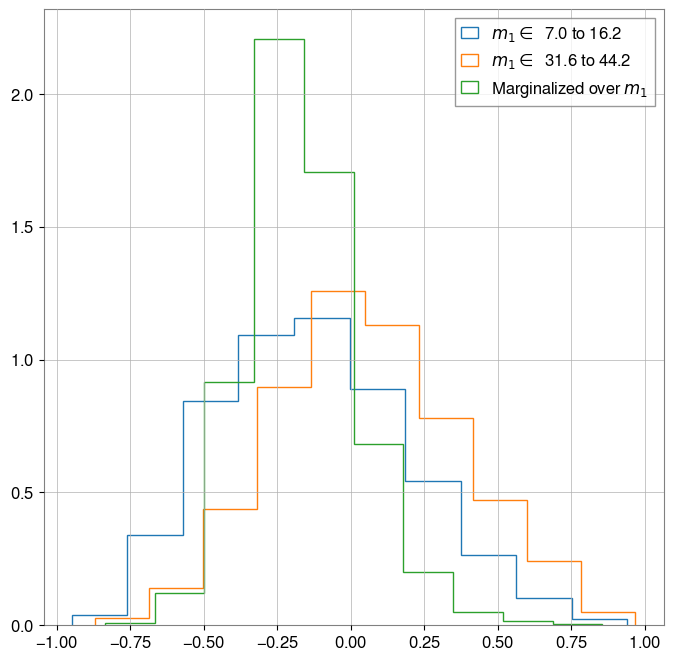

In [29]:
fig, ax = plt.subplots(1, figsize=(8,8))


ax.hist(rho_m1_7p5_to_15_test, histtype='step', density = True)
ax.hist(rho_m1_30_to_40_test, histtype='step', density = True)
ax.hist(rho_m1_full_test, histtype='step', density = True)


ax.legend([r'$m_1 \in$  '+str(7.0)+' to '+str(16.2), r'$m_1 \in$  '+str(31.6)+' to '+str(44.2), 'Marginalized over $m_1$'])
plt.show()

# 2d median plots

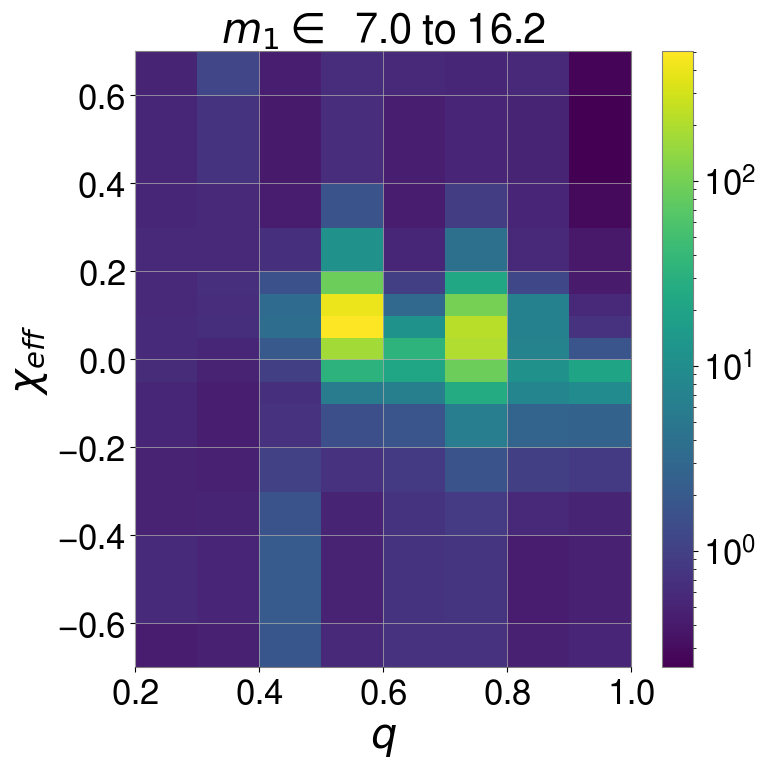

In [32]:
fig,axes = plt.subplots(1,figsize =(8,8))
ax = axes
matrix1 = pp_utils.get_two_d_q_chi_with_q(n_corr_samples, dm1, 7, 16.2)

pc = ax.pcolor(qbins,chi_bins,matrix1.T,norm=LogNorm(vmin=matrix1[matrix1!=0].min(),vmax=matrix1.max()),cmap='viridis')
#ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_xlabel(r'$q$',fontsize=fs)
ax.set_ylabel(r'$\chi_{eff}$',fontsize=fs)
ax.tick_params(labelsize = fs-5)

cbar = fig.colorbar(pc, ax = ax)
cbar.ax.tick_params(labelsize = fs-5)

plt.title(r'$m_1 \in$  '+str(7.0)+' to '+str(16.2),fontsize=fs)
plt.show()

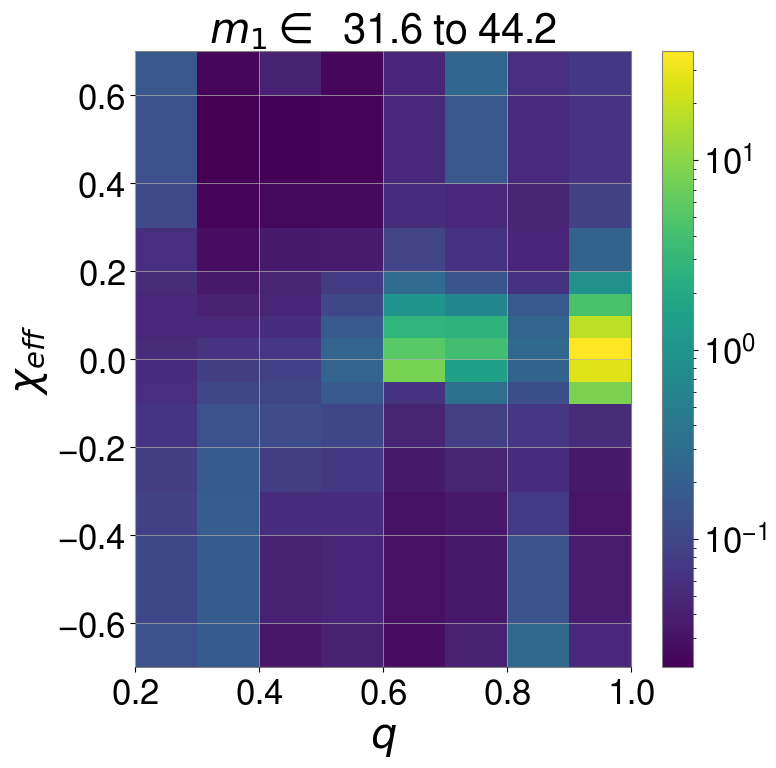

In [31]:
fig,axes = plt.subplots(1,figsize =(8,8))
#for i in range(len(chi_bins)-1):
ax = axes
#ax.set_title(r'$\chi_{eff}$ bin center = '+str(int(1000*0.5*(chi_bins[i+1]+chi_bins[i]))/1000))
matrix1 = pp_utils.get_two_d_q_chi_with_q(n_corr_samples, dm1, 31.6, 44.2)

pc = ax.pcolor(qbins,chi_bins,matrix1.T,norm=LogNorm(vmin=matrix1[matrix1!=0].min(),vmax=matrix1.max()),cmap='viridis')
#ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_xlabel(r'$q$',fontsize=fs)
ax.set_ylabel(r'$\chi_{eff}$',fontsize=fs)
ax.tick_params(labelsize = fs-5)

cbar = fig.colorbar(pc, ax = ax)
cbar.ax.tick_params(labelsize = fs-5)


plt.title(r'$m_1 \in$  '+str(31.6)+' to '+str(44.2),fontsize=fs)
plt.show()

# Marginal probability distribution plots

In [33]:
mass1,Rpm1_corr1 = pp_utils.get_Rpm1_q_corr_with_q(n_corr_samples,dq,d_chis,mbins,chi_bins,log_bin_centers,0.2,1.)

(2178,) (34430, 2179)


In [34]:
fig, ax = plt.subplots(1,dpi = 500, tight_layout = True, figsize=(18*1.3,12*1.3))
matplotlib.rcParams.update({'font.size': 70})

Rp_m1=np.array(Rpm1_corr1)/np.trapz(Rpm1_corr1,mass1,axis=1)[:,None]
Rpm_5 = np.percentile(Rp_m1,q=5,axis=0)
Rpm_95 = np.percentile(Rp_m1,q=95,axis=0)
R_pm_med = np.percentile(Rp_m1,q=50,axis=0)
ax.fill_between(mass1,Rpm_5,Rpm_95,alpha=0.3,color=colors[0])
ax.plot(mass1,R_pm_med,color=colors[0],linewidth=4.0)

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim(5,200)


ax.set_xlabel(r'$m_1~\left[M_{\odot}\right]$',fontsize=fs)
ax.set_ylabel(r'$p(m_1)$',fontsize=fs)
ax.tick_params(axis='both', which='major', labelsize=int(fs*0.8))
ax.tick_params(axis='both', which='minor', labelsize=int(fs*0.8))
#ax.legend(fontsize=fs*0.58, framealpha=0.,ncol=1,loc='lower center')
ax.xaxis.label.set_size(fs)
ax.yaxis.label.set_size(fs)
fig.tight_layout()
ax.grid(linestyle=':',linewidth=3)
plt.show()

In [35]:
mrat2,Rpq_corr2 = pp_utils.get_Rpq_corr_with_q(n_corr_samples,dm1,d_chis,mbins,qbins,log_bin_centers,-0.7,0.7)

(34430, 793)


In [36]:
fig, ax = plt.subplots(1,dpi = 500, tight_layout = True, figsize=(18*1.3,12*1.3))
matplotlib.rcParams.update({'font.size': 70})

Rp_q1=np.array(Rpq_corr2)/np.trapz(Rpq_corr2,mrat2,axis=1)[:,None]
Rpq_5 = np.percentile(Rp_q1,q=5,axis=0)
Rpq_95 = np.percentile(Rp_q1,q=95,axis=0)
R_pm_med = np.percentile(Rp_q1,q=50,axis=0)
ax.fill_between(mrat2,Rpq_5,Rpq_95,alpha=0.3,color=colors[1],label=r'$\chi_{eff} \in (-0.7,0.7)$')
ax.plot(mrat2,R_pm_med,color=colors[1],linewidth=4.0)
ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlim(0.1,1)

ax.set_ylim(5e-3,20)
ax.set_xlim(0.2,1)
ax.set_xlabel(r'$q$',fontsize=fs)
ax.set_ylabel(r'$p(q)$',fontsize=fs)
ax.tick_params(axis='both', which='major', labelsize=int(fs*0.8))
ax.tick_params(axis='both', which='minor', labelsize=int(fs*0.8))
#ax.legend(fontsize=fs*0.58, framealpha=0.,ncol=1,loc='lower left')
ax.xaxis.label.set_size(fs)
ax.yaxis.label.set_size(fs)
fig.tight_layout()
ax.grid(linestyle=':',linewidth=3)
plt.show()

In [37]:
mrat1,Rpq_corr1 = pp_utils.get_Rpq_corr_m1chi_with_q(n_corr_samples,dm1,d_chis,mbins,qbins,log_bin_centers,mbins[2], mbins[7],-0.7,0.7)
mrat2,Rpq_corr2 = pp_utils.get_Rpq_corr_m1chi_with_q(n_corr_samples,dm1,d_chis,mbins,qbins,log_bin_centers,mbins[11],mbins[13],-0.7,0.7)

(34430, 793)
(34430, 793)


In [38]:
fig, ax = plt.subplots(1,dpi = 500, tight_layout = True, figsize=(18*1.3,12*1.3))
matplotlib.rcParams.update({'font.size': 70})

Rp_q1=np.array(Rpq_corr1)/np.trapz(Rpq_corr1,mrat2,axis=1)[:,None]
Rpq_5 = np.percentile(Rp_q1,q=5,axis=0)
Rpq_95 = np.percentile(Rp_q1,q=95,axis=0)
R_pq_med = np.percentile(Rp_q1,q=50,axis=0)
ax.fill_between(mrat2,Rpq_5,Rpq_95,alpha=0.3,label=f"$m_1 \in ({mbins[2]},{mbins[7]})$",color=colors[0])
ax.plot(mrat2,R_pq_med,color=colors[0],linewidth=4.0)

Rp_q1=np.array(Rpq_corr2)/np.trapz(Rpq_corr2,mrat2,axis=1)[:,None]
Rpq_5 = np.percentile(Rp_q1,q=5,axis=0)
Rpq_95 = np.percentile(Rp_q1,q=95,axis=0)
R_pm_med = np.percentile(Rp_q1,q=50,axis=0)
ax.fill_between(mrat2,Rpq_5,Rpq_95,alpha=0.3,color=colors[1],label=f"$m_1 \in ({mbins[11]},{mbins[13]})$")
ax.plot(mrat2,R_pm_med,color=colors[1],linewidth=4.0)
ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlim(0.1,1)

ax.set_ylim(1e-3,15)
ax.set_xlim(0.2,1)
ax.set_xlabel(r'$q$',fontsize=fs)
ax.set_ylabel(r'$p(q|m_1)$',fontsize=fs)
ax.tick_params(axis='both', which='major', labelsize=int(fs*0.8))
ax.tick_params(axis='both', which='minor', labelsize=int(fs*0.8))
ax.legend(fontsize=fs*0.58, framealpha=0.,ncol=1,loc='lower left')
ax.xaxis.label.set_size(fs)
ax.yaxis.label.set_size(fs)
fig.tight_layout()
ax.grid(linestyle=':',linewidth=3)
plt.show()

In [39]:
chi, Rp_chi_1 = pp_utils.get_Rpchi_q_with_q(log_bin_centers,n_corr_samples,chi_bins,dm1,dq,0.2,1)

In [40]:
fig, ax = plt.subplots(1,dpi = 500, tight_layout = True, figsize=(18*1.3,12*1.3))
matplotlib.rcParams.update({'font.size': 70})
Rp_m1=Rp_chi_1/np.trapz(Rp_chi_1,chi,axis=1)[:,None]

Rpm_5 = np.percentile(Rp_m1,q=5,axis=0)
Rpm_95 = np.percentile(Rp_m1,q=95,axis=0)
R_pm_med = np.percentile(Rp_m1,q=50,axis=0)
ax.fill_between(chi,Rpm_5,Rpm_95,alpha=0.3,color=colors[0])

ax.plot(chi,R_pm_med,color=colors[0],linewidth=4.0)
ax.set_yscale('log')
ax.set_xlim(-0.6,0.6)
ax.set_ylim(1e-3,30)

ax.set_xlabel(r'$\chi_{eff}$',fontsize=fs)
ax.set_ylabel(r'$p(\chi_{eff})$',fontsize=fs)
ax.tick_params(axis='both', which='major', labelsize=int(fs*0.8))
ax.tick_params(axis='both', which='minor', labelsize=int(fs*0.8))
#ax.legend(fontsize=fs*0.58, framealpha=0.,ncol=1,loc='lower center')#,loc='lower right')
ax.xaxis.label.set_size(fs)
ax.yaxis.label.set_size(fs)
fig.tight_layout()
ax.grid(linestyle=':',linewidth=3)
plt.show()